In [ ]:
# Analisi della diffusione del COVID-19 e delle vaccinazioni nel mondo

## Introduzione

# L'obiettivo del progetto è analizzare l'andamento della pandemia COVID-19 attraverso il dataset pubblico fornito da Our World in Data (OWID).

# L'analisi riguarda:
- diffusione dei casi nel tempo;
- andamento delle vaccinazioni;
- confronto tra paesi e continenti;
- comprensione della struttura e qualità dei dati.

Il dataset contiene informazioni epidemiologiche raccolte quotidianamente a livello globale.

Fonte ufficiale:
https://github.com/owid/covid-19-data

In [ ]:
## Obiettivi del progetto

La traccia richiede di:

# 1. Effettuare un'analisi esplorativa del dataset (EDA);
# 2. Comprendere la struttura dei dati e i relativi metadati;
# 3. Analizzare le colonne `continent` e `location`;
# 4. Comprendere la differenza tra `new_cases` e `total_cases`;
# 5. Analizzare casi COVID e vaccinazioni in diverse aree del mondo;
# 6. Produrre visualizzazioni e interpretazioni dei risultati.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"

df = pd.read_csv(url)

In [3]:
# Exploratory Data Analysis (EDA)

# Prima di effettuare qualsiasi analisi è necessario comprendere:
#- dimensioni del dataset;
#- struttura dei dati;
# tipologie delle colonne;
# presenza di valori mancanti;
# qualità generale del dataset.

df.shape
df.head()

print("Numero righe:", df.shape[0])  # rilevazione giornaliera
print("Numero colonne:", df.shape[1]) # variabile epidemiologica, sanitaria, demografica o economica

Numero righe: 429435
Numero colonne: 67


In [4]:
df.info()

df.columns

df.dtypes

df.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

weekly_icu_admissions_per_million          418442
weekly_icu_admissions                      418442
excess_mortality_cumulative_per_million    416024
excess_mortality                           416024
excess_mortality_cumulative                416024
                                            ...  
total_deaths                                17631
population                                      0
date                                            0
location                                        0
iso_code                                        0
Length: 67, dtype: int64

In [ ]:
# Il dataset contiene 429.435 osservazioni e 67 variabili.

Ogni riga rappresenta una rilevazione giornaliera per un determinato paese o area geografica.

# Le colonne sono eterogenee e includono:
- dati epidemiologici (casi, decessi)
- dati sanitari (ricoveri, ICU)
- dati sulle vaccinazioni
- indicatori socio-economici e demografici

# Il dataset presenta una forte presenza di valori mancanti, soprattutto nelle variabili relative a:
- terapie intensive
- ospedalizzazioni settimanali
- indicatori di mortalità in eccesso

Questo è normale nei dataset reali di grande scala, poiché non tutti i paesi raccolgono le stesse informazioni con la stessa frequenza.
    
# Alcune variabili risultano quasi completamente vuote.

# Questo indica che tali dati non sono disponibili per la maggior parte dei paesi o non sono stati raccolti in modo sistematico durante tutta la pandemia.

In [5]:
# continent e location

df["location"].unique()

df[df["continent"].isna()]["location"].unique()

array(['Africa', 'Asia', 'Europe', 'European Union (27)',
       'High-income countries', 'Low-income countries',
       'Lower-middle-income countries', 'North America', 'Oceania',
       'South America', 'Upper-middle-income countries', 'World'],
      dtype=object)

In [ ]:
# Dall'analisi emerge che le righe con `continent = NaN` non rappresentano paesi reali, ma aggregazioni geografiche o economiche.


In [31]:
# strutturare solo paesi reali - esclusi aggregati - dataset pulito per analisi

df_countries = df[df["continent"].notna()].copy()

In [ ]:
# 2 task “Per ogni continente:

a) numero di casi dall’inizio pandemia
b) percentuale rispetto al totale mondiale”

In [10]:
df_countries = df[df["continent"].notna()].copy()

#sommiamo i casi per continente

continent_cases = df_countries.groupby("continent")["new_cases"].sum()
df_countries.shape
continent_cases = df_countries.groupby("continent")["new_cases"].sum()
continent_cases

continent
Africa            13146831.0
Asia             301564180.0
Europe           252916868.0
North America    124492698.0
Oceania           15003468.0
South America     68811012.0
Name: new_cases, dtype: float64

In [11]:
# calcolare il totale globale dei casi
world_cases = df_countries["new_cases"].sum()
world_cases


np.float64(775935057.0)

In [12]:
# percentuale per ogni continente sul totale mondiale
continent_percentage = (continent_cases / world_cases) * 100
continent_percentage

continent
Africa            1.694321
Asia             38.864616
Europe           32.595108
North America    16.044216
Oceania           1.933598
South America     8.868141
Name: new_cases, dtype: float64

In [13]:
result = pd.DataFrame({
    "total_cases": continent_cases,
    "percentage_world": continent_percentage
})

result.sort_values("total_cases", ascending=False)

,total_cases,percentage_world
continent,,
Asia,301564180.0,38.864616
Europe,252916868.0,32.595108
North America,124492698.0,16.044216
South America,68811012.0,8.868141
Oceania,15003468.0,1.933598
Africa,13146831.0,1.694321


In [ ]:
# Per ogni continente sono stati calcolati:
- il numero totale di casi COVID-19 dall’inizio della pandemia (somma dei nuovi casi giornalieri)
- la percentuale rispetto al totale mondiale

# Questo permette di confrontare il peso relativo della pandemia tra le diverse aree geografiche.

In [ ]:
# task 3 a. l'evoluzione del casi totali dall'inizio alla fine dell'anno e b. il numero di nuovi casi rispetto alla data

In [20]:
# CONVERSIONE DATA
df_countries["date"] = pd.to_datetime(df_countries["date"])

# filtrare dati in italia, nel 2022
italy_2022 = df_countries[
    (df_countries["location"] == "Italy") &
    (df_countries["date"].dt.year == 2022)
].copy()

# filtrare via i giorni che non hanno misurazioni

italy_2022 = italy_2022.dropna(subset=["total_cases", "new_cases"])

italy_2022.shape
italy_2022.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
186002,ITA,Europe,Italy,2022-01-01,5622431.0,0.0,36797.00,136530.0,0.0,140.86,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186003,ITA,Europe,Italy,2022-01-02,6267035.0,644604.0,92086.29,137513.0,983.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,168226.3,12.99,8.06,2849.48
186004,ITA,Europe,Italy,2022-01-03,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186005,ITA,Europe,Italy,2022-01-04,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186006,ITA,Europe,Italy,2022-01-05,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN


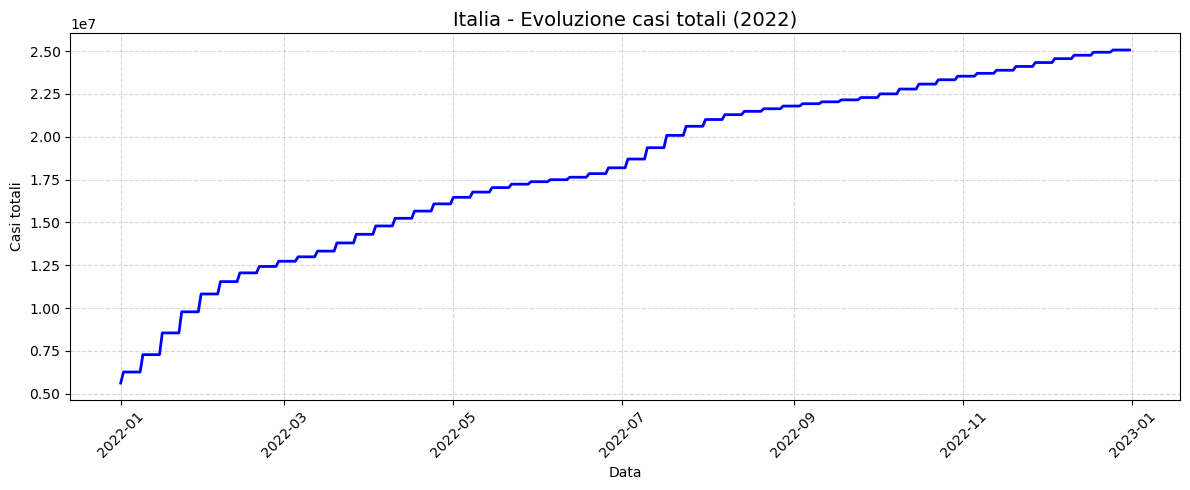

In [24]:
# Rappresentazione di un grafico che mostra l’evoluzione cumulativa dei casi totali in Italia durante il 2022

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    italy_2022["date"],
    italy_2022["total_cases"],
    linewidth=2,
    color="blue"
)

plt.title("Italia - Evoluzione casi totali (2022)", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Casi totali")

plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

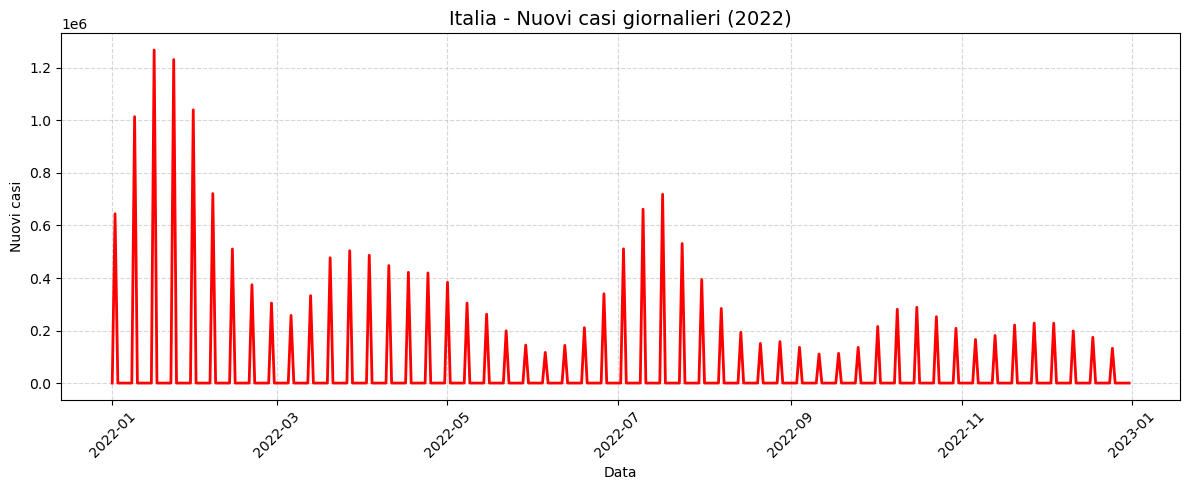

In [25]:
# Rappresentazione di un grafico che mostra l’andamento dei nuovi casi giornalieri

plt.figure(figsize=(12,5))

plt.plot(
    italy_2022["date"],
    italy_2022["new_cases"],
    linewidth=2,
    color="red"
)

plt.title("Italia - Nuovi casi giornalieri (2022)", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Nuovi casi")

plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Task 4 
# a.) Mostro in un boxplot la differenza tra queste nazioni (Italia, Germania e Francia) riguardo il numero di pazienti in terapia intensiva 
    # (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso)
# b.) Scrivo un breve commento riguardo che conclusioni possiamo trarre osservando il grafico risultante

<Figure size 800x500 with 0 Axes>

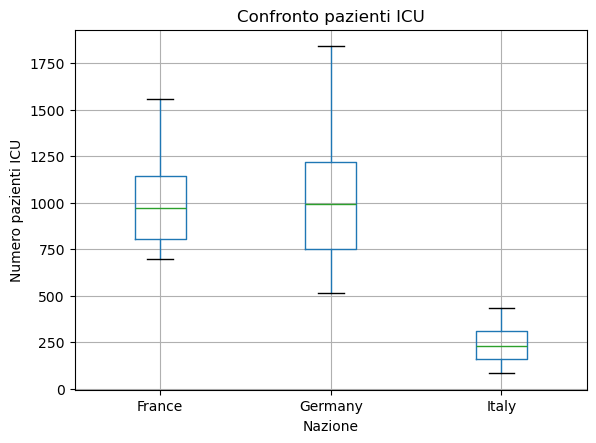

In [27]:
# in questa prima operazione Vengono selezionati i dati relativi a Italia, Germania e Francia nel periodo compreso tra maggio 2022 e aprile 2023

df_countries["date"] = pd.to_datetime(df_countries["date"])

df_icu = df_countries[
    (df_countries["location"].isin(["Italy", "Germany", "France"])) &
    (df_countries["date"] >= "2022-05-01") &
    (df_countries["date"] <= "2023-04-30")
].copy()


# Rimuovo i record privi di misurazioni relative ai pazienti in terapia intensiva

df_icu = df_icu.dropna(subset=["icu_patients"])


#Creazione del Boxplot per i 3 diversi paese, per il loro confronto 

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df_icu.boxplot(column="icu_patients", by="location")

plt.title("Confronto pazienti ICU")
plt.suptitle("")

plt.xlabel("Nazione")
plt.ylabel("Numero pazienti ICU")

plt.show()

In [ ]:
# Il boxplot evidenzia differenze nella distribuzione dei pazienti in terapia intensiva tra Italia, Germania e Francia, mostrando variazioni nei valori mediani e nella dispersione dei dati.

In [29]:
# Task 5 ( ultima) Selezione dei dati relativi a Italia, Germania, Francia e Spagna nel corso del 2021 per analizzare il numero di pazienti ospedalizzati

df_hosp = df_countries[
    (df_countries["location"].isin(["Italy", "Germany", "France", "Spain"])) &
    (df_countries["date"].dt.year == 2021)
].copy()

# controllo dei valori nulli
df_hosp["hosp_patients"].isnull().sum()

#somma dei pazienti ospedalizzati

hosp_sum = df_hosp.groupby("location")["hosp_patients"].sum()

hosp_sum

location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64

<Axes: xlabel='location'>

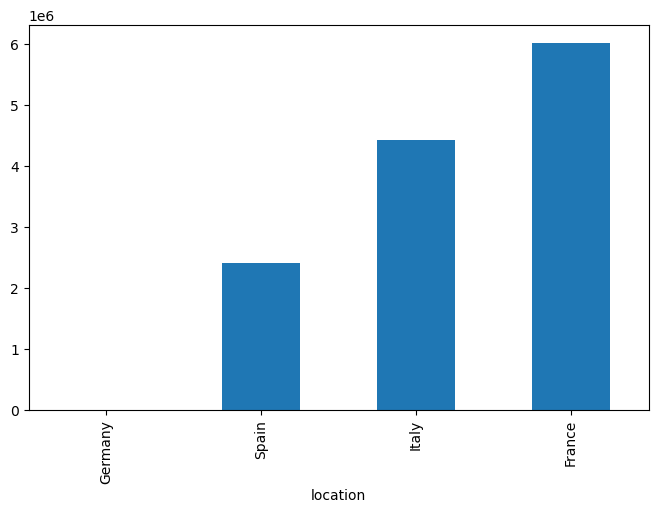

In [30]:
hosp_sum.sort_values().plot(kind="bar", figsize=(8,5))

In [ ]:
# a conclusione di quest'ultimo punto, risulta che sono alcuni valori mancanti nella colonna `hosp_patients`, che indicano giorni in cui i dati non sono stati registrati.

# In questo caso non è opportuno sostituire questi valori, perché le ospedalizzazioni cambiano nel tempo e una sostituzione potrebbe falsare i risultati.

In [ ]:
# ## Sunto sul Progetto:

# L’analisi ha permesso di capire come è cambiata la pandemia di COVID-19 nel tempo e nei diversi paesi e continenti.

# Si è visto che la diffusione del virus e l’impatto sugli ospedali non sono stati uguali ovunque, ma variano molto tra le diverse aree.

# Il dataset ha richiesto una fase iniziale di pulizia per poter lavorare correttamente sui dati e distinguere tra paesi singoli e dati aggregati.

# In generale, prima di fare analisi più approfondite è importante sempre esplorare bene i dati.